In [1]:
# import os
# os.environ["USE_TORCH"] = "0"
# os.environ["USE_TF"] = "0"

from datasets import load_dataset
ds = load_dataset("abisee/cnn_dailymail", "1.0.0")

c:\Users\czajk\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
df = pd.concat([ds[split].to_pandas() for split in ds.keys()], ignore_index=True)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (311971, 3)
Columns: ['article', 'highlights', 'id']


,article,highlights,id
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,42c027e4ff9730fbb3de84c1af0d2c506e41c3e4
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,ee8871b15c50d0db17b0179a6d2beab35065f1e9
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",06352019a19ae31e527f37f7571c6dd7f0c5da37
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",24521a2abb2e1f5e34e6824e0f9e56904a2b0e88
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical...",7fe70cc8b12fab2d0a258fababf7d9c6b5e1262a


In [3]:
from transformers import pipeline
import pandas as pd

# Load model
sentiment = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,      # articles are long, this truncates to model max (512 tokens)
    max_length=512
)

# Grab a small sample
sample = ds["train"].to_pandas().head(5)

# Run sentiment
results = sentiment(sample["article"].tolist())

# Combine with original
sample["sentiment_label"] = [r["label"] for r in results]
sample["sentiment_score"] = [r["score"] for r in results]

print(sample[["article", "sentiment_label", "sentiment_score"]].to_string())

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 18307.39it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\czajk\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\czajk\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your dis

In [4]:
import pandas as pd

# Grab 500 articles
sample = ds["train"].to_pandas().head(500)

# Run sentiment in batches to avoid memory issues
results = []
batch_size = 32

for i in range(0, len(sample), batch_size):
    batch = sample["article"].iloc[i:i+batch_size].tolist()
    batch_results = sentiment(batch)
    results.extend(batch_results)
    print(f"Processed {min(i+batch_size, 500)}/500")

sample["sentiment_label"] = [r["label"] for r in results]
sample["sentiment_score"] = [r["score"] for r in results]

# Save to CSV
sample[["article", "highlights", "sentiment_label", "sentiment_score"]].to_csv("sentiment_results.csv", index=False)
print("Done! Saved to sentiment_results.csv")

Processed 32/500
Processed 64/500
Processed 96/500
Processed 128/500
Processed 160/500
Processed 192/500
Processed 224/500
Processed 256/500
Processed 288/500
Processed 320/500
Processed 352/500
Processed 384/500
Processed 416/500
Processed 448/500
Processed 480/500
Processed 500/500
Done! Saved to sentiment_results.csv


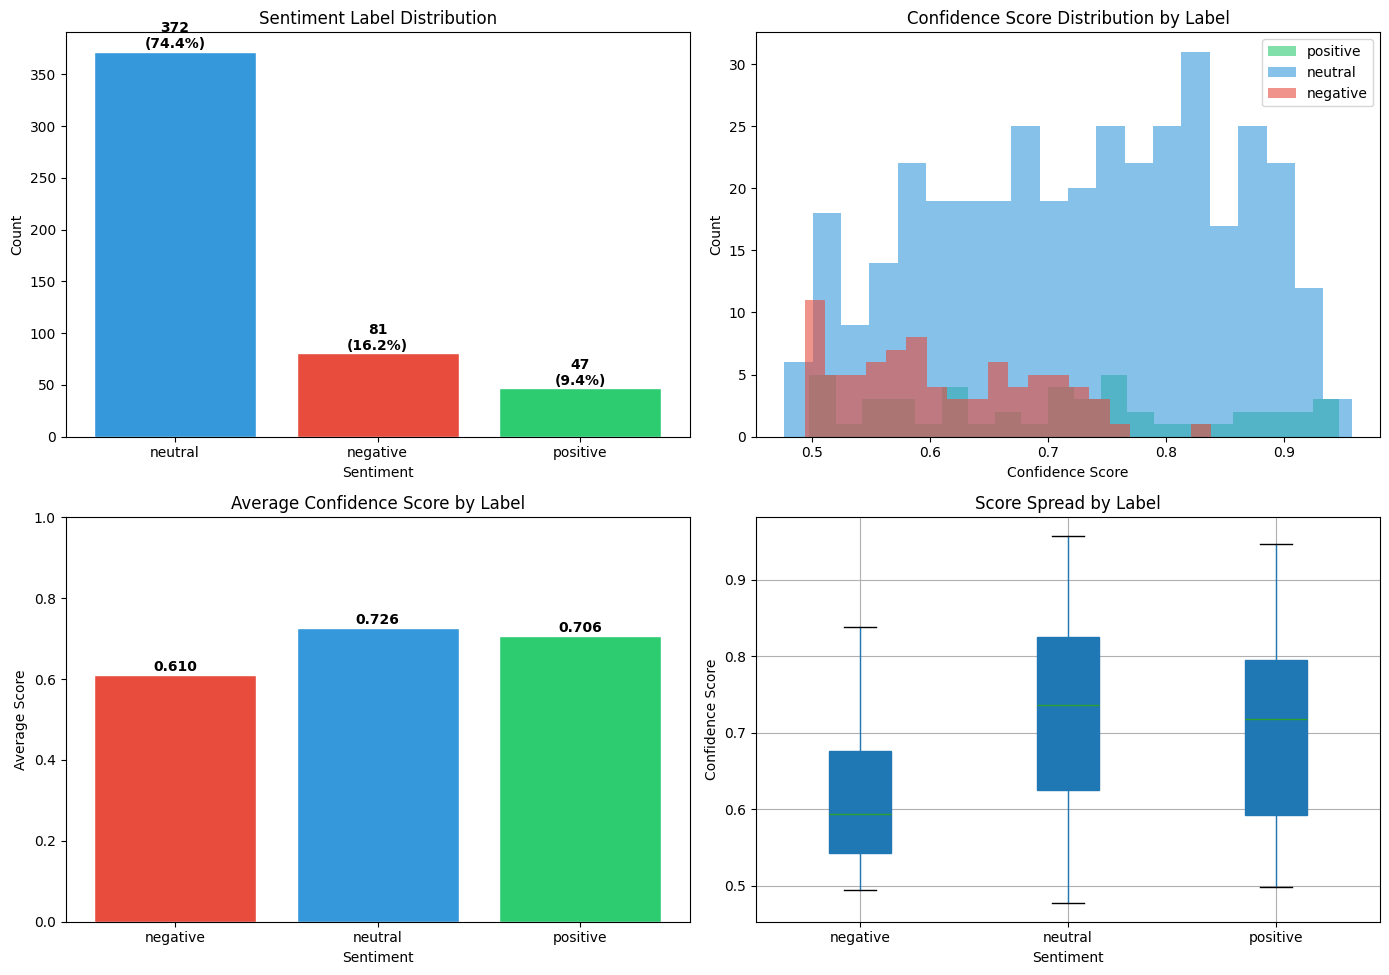

sentiment_label
neutral     372
negative     81
positive     47
Name: count, dtype: int64

Mean confidence: 0.705


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("sentiment_results.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Sentiment Analysis of CNN/DailyMail Articles (n=500)", fontsize=16, fontweight="bold")

# 1. Label distribution
label_counts = df["sentiment_label"].value_counts()
colors = {"positive": "#2ecc71", "neutral": "#3498db", "negative": "#e74c3c"}
axes[0, 0].bar(label_counts.index, label_counts.values, 
               color=[colors[l] for l in label_counts.index], edgecolor="white")
axes[0, 0].set_title("Sentiment Label Distribution")
axes[0, 0].set_xlabel("Sentiment")
axes[0, 0].set_ylabel("Count")
for i, (label, count) in enumerate(label_counts.items()):
    axes[0, 0].text(i, count + 3, f"{count}\n({count/len(df)*100:.1f}%)", 
                    ha="center", fontweight="bold")

# 2. Score distribution by label
for label, color in colors.items():
    subset = df[df["sentiment_label"] == label]["sentiment_score"]
    if len(subset) > 0:
        axes[0, 1].hist(subset, bins=20, alpha=0.6, label=label, color=color)
axes[0, 1].set_title("Confidence Score Distribution by Label")
axes[0, 1].set_xlabel("Confidence Score")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# 3. Average confidence per label
avg_scores = df.groupby("sentiment_label")["sentiment_score"].mean()
axes[1, 0].bar(avg_scores.index, avg_scores.values,
               color=[colors[l] for l in avg_scores.index], edgecolor="white")
axes[1, 0].set_title("Average Confidence Score by Label")
axes[1, 0].set_xlabel("Sentiment")
axes[1, 0].set_ylabel("Average Score")
axes[1, 0].set_ylim(0, 1)
for i, (label, score) in enumerate(avg_scores.items()):
    axes[1, 0].text(i, score + 0.01, f"{score:.3f}", ha="center", fontweight="bold")

# 4. Score boxplot
df.boxplot(column="sentiment_score", by="sentiment_label", ax=axes[1, 1],
           patch_artist=True)
axes[1, 1].set_title("Score Spread by Label")
axes[1, 1].set_xlabel("Sentiment")
axes[1, 1].set_ylabel("Confidence Score")
plt.suptitle("")  # suppress auto title from boxplot

plt.tight_layout()
plt.savefig("sentiment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(df["sentiment_label"].value_counts())
print(f"\nMean confidence: {df['sentiment_score'].mean():.3f}")

In [35]:
import pandas as pd
import time
import os

# Load the data
full_df = ds["train"].to_pandas()
print(f"Total articles: {len(full_df)}")

checkpoint_file = "sentiment_checkpoint.csv"
batch_size = 16      # smaller batches = less heat
delay = 2            # seconds to wait between batches

# Resume from checkpoint if it exists
if os.path.exists(checkpoint_file):
    checkpoint = pd.read_csv(checkpoint_file)
    start_idx = len(checkpoint)
    print(f"Resuming from article {start_idx}")
else:
    checkpoint = pd.DataFrame(columns=["sentiment_label", "sentiment_score"])
    start_idx = 0
    print("Starting fresh")

# Run in batches
for i in range(start_idx, len(full_df), batch_size):
    batch = full_df["article"].iloc[i:i+batch_size].tolist()
    
    try:
        results = sentiment(batch)
    except Exception as e:
        print(f"Error at batch {i}: {e}")
        break

    batch_df = pd.DataFrame({
        "sentiment_label": [r["label"] for r in results],
        "sentiment_score": [r["score"] for r in results]
    })

    checkpoint = pd.concat([checkpoint, batch_df], ignore_index=True)

    # Save every 64 articles
    if i % 64 == 0:
        checkpoint.to_csv(checkpoint_file, index=False)
        print(f"Progress: {min(i+batch_size, len(full_df))}/{len(full_df)} saved ✓")

    time.sleep(delay)

# Final save
checkpoint.to_csv(checkpoint_file, index=False)
print(f"Done! {len(checkpoint)} articles processed.")

Total articles: 287113
Resuming from article 126608
Progress: 126672/287113 saved ✓
Progress: 126736/287113 saved ✓
Progress: 126800/287113 saved ✓
Progress: 126864/287113 saved ✓
Progress: 126928/287113 saved ✓
Progress: 126992/287113 saved ✓
Progress: 127056/287113 saved ✓


KeyboardInterrupt: 

In [26]:
import pandas as pd

# Load checkpoint and full data
checkpoint = pd.read_csv("sentiment_checkpoint.csv")
full_df = pd.concat([
    ds["train"].to_pandas(),
    ds["validation"].to_pandas(),
    ds["test"].to_pandas()
], ignore_index=True)

# Merge by index — only take rows that are done
df = full_df.head(len(checkpoint)).copy()
df["sentiment_label"] = checkpoint["sentiment_label"].values
df["sentiment_score"] = checkpoint["sentiment_score"].values

print(f"Articles analysed so far: {len(df)}")
print(df["sentiment_label"].value_counts())

Articles analysed so far: 126608
sentiment_label
neutral     99247
negative    15403
positive    11958
Name: count, dtype: int64


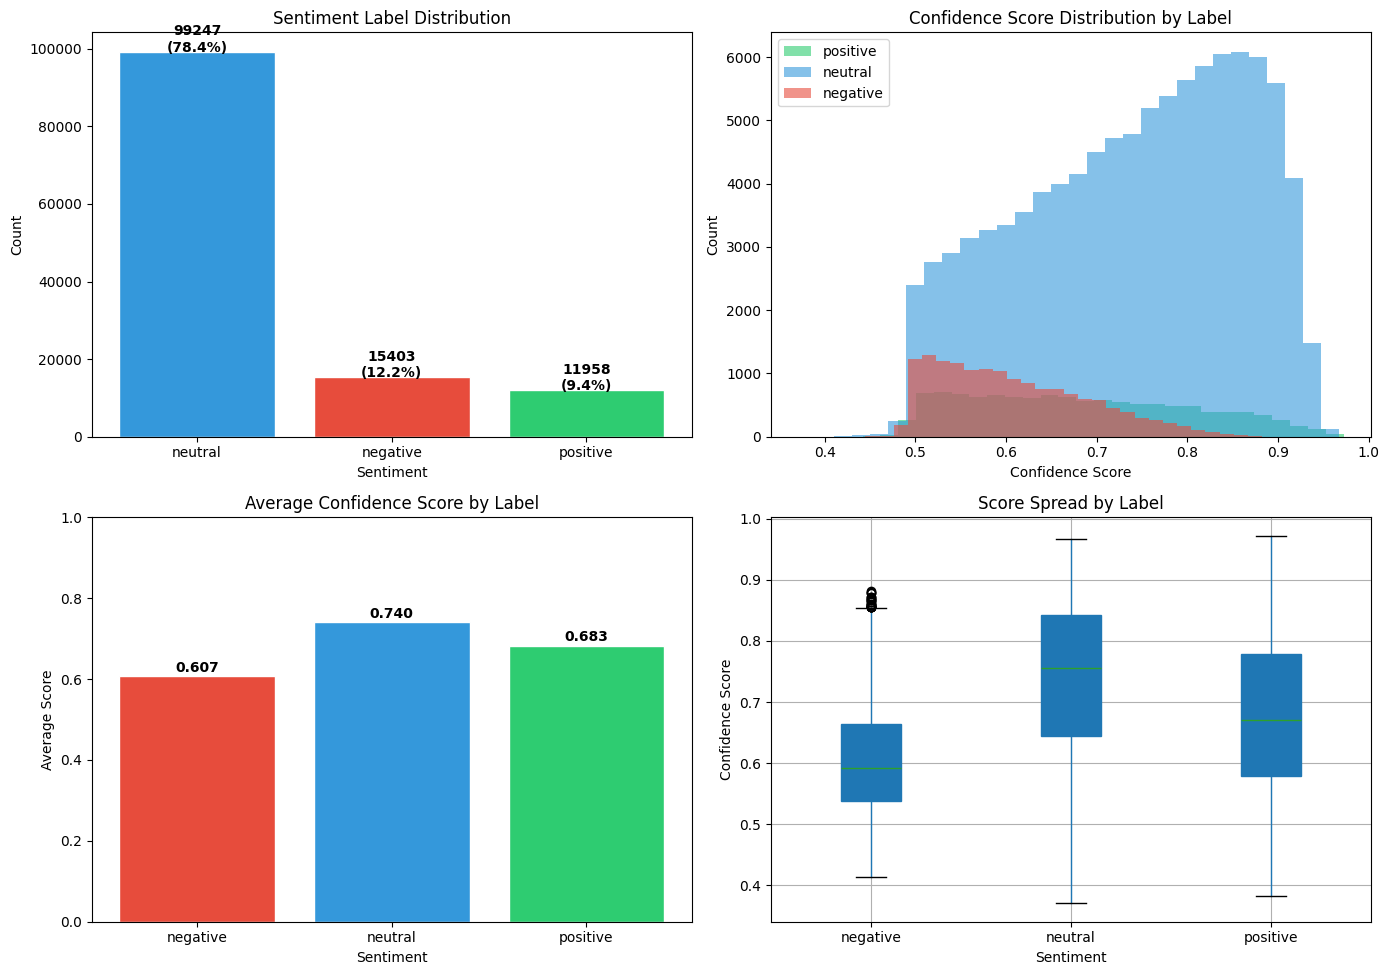

In [27]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Sentiment Analysis of CNN/DailyMail Articles (n={len(df):,})", fontsize=16, fontweight="bold")

colors = {"positive": "#2ecc71", "neutral": "#3498db", "negative": "#e74c3c"}

# 1. Label distribution
label_counts = df["sentiment_label"].value_counts()
axes[0, 0].bar(label_counts.index, label_counts.values,
               color=[colors[l] for l in label_counts.index], edgecolor="white")
axes[0, 0].set_title("Sentiment Label Distribution")
axes[0, 0].set_xlabel("Sentiment")
axes[0, 0].set_ylabel("Count")
for i, (label, count) in enumerate(label_counts.items()):
    axes[0, 0].text(i, count + 10, f"{count}\n({count/len(df)*100:.1f}%)", ha="center", fontweight="bold")

# 2. Score distribution by label
for label, color in colors.items():
    subset = df[df["sentiment_label"] == label]["sentiment_score"]
    if len(subset) > 0:
        axes[0, 1].hist(subset, bins=30, alpha=0.6, label=label, color=color)
axes[0, 1].set_title("Confidence Score Distribution by Label")
axes[0, 1].set_xlabel("Confidence Score")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# 3. Average confidence per label
avg_scores = df.groupby("sentiment_label")["sentiment_score"].mean()
axes[1, 0].bar(avg_scores.index, avg_scores.values,
               color=[colors[l] for l in avg_scores.index], edgecolor="white")
axes[1, 0].set_title("Average Confidence Score by Label")
axes[1, 0].set_xlabel("Sentiment")
axes[1, 0].set_ylabel("Average Score")
axes[1, 0].set_ylim(0, 1)
for i, (label, score) in enumerate(avg_scores.items()):
    axes[1, 0].text(i, score + 0.01, f"{score:.3f}", ha="center", fontweight="bold")

# 4. Boxplot
df.boxplot(column="sentiment_score", by="sentiment_label", ax=axes[1, 1], patch_artist=True)
axes[1, 1].set_title("Score Spread by Label")
axes[1, 1].set_xlabel("Sentiment")
axes[1, 1].set_ylabel("Confidence Score")
plt.suptitle("")

plt.tight_layout()
plt.savefig("sentiment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# Merge sentiment with NER on id
df_sentiment = full_df.head(len(checkpoint)).copy()
df_sentiment["sentiment_label"] = checkpoint["sentiment_label"].values
df_sentiment["sentiment_score"] = checkpoint["sentiment_score"].values

df = df_sentiment.merge(ner[["id", "primary_country"]], on="id", how="inner")

# Merge with structural on iso2 = primary_country
df = df.merge(structural, left_on="primary_country", right_on="iso2", how="left")

print(f"Final shape: {df.shape}")
print(f"Global North/South counts:")
print(df["global_north_or_south"].value_counts())
print(f"\nSentiment counts:")
print(df["sentiment_label"].value_counts())

Final shape: (5000, 11)
Global North/South counts:
global_north_or_south
Global North    3021
Global South    1783
Name: count, dtype: int64

Sentiment counts:
sentiment_label
neutral     3718
negative     731
positive     551
Name: count, dtype: int64


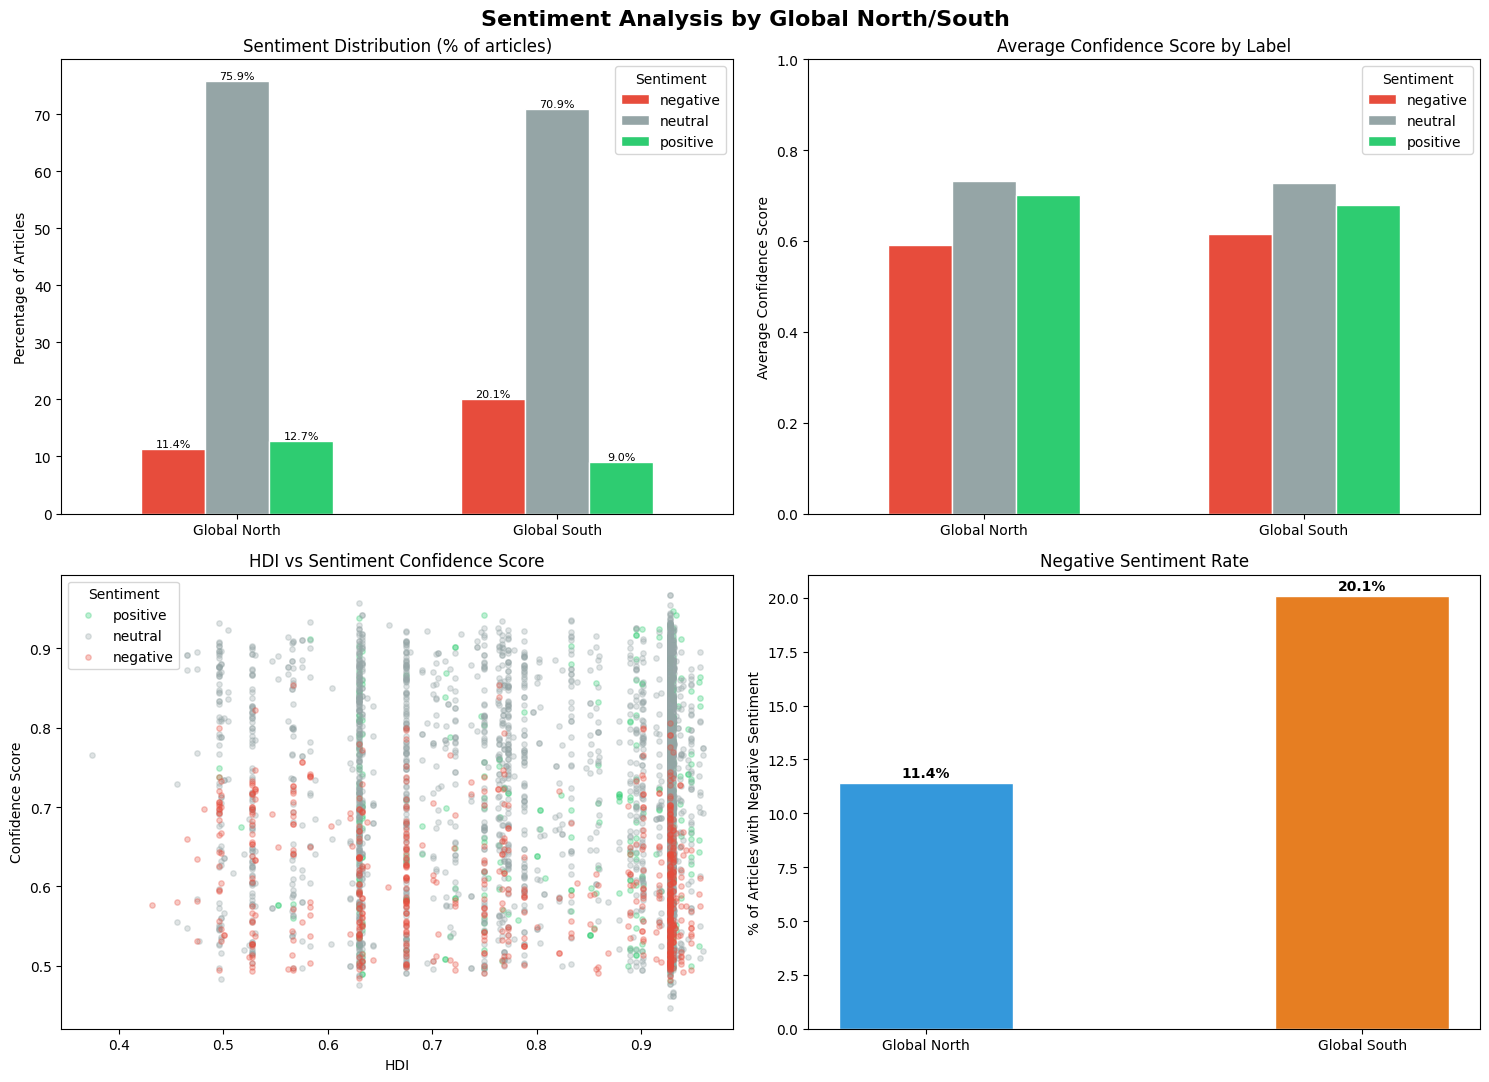

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Filter to only rows with a north/south label
df_ns = df.dropna(subset=["global_north_or_south"])

colors_ns = {"Global North": "#3498db", "Global South": "#e67e22"}
colors_sent = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Sentiment Analysis by Global North/South", fontsize=16, fontweight="bold")

# 1. Sentiment distribution by North/South (percentage)
sent_by_ns = df_ns.groupby(["global_north_or_south", "sentiment_label"]).size().unstack(fill_value=0)
sent_by_ns_pct = sent_by_ns.div(sent_by_ns.sum(axis=1), axis=0) * 100
sent_by_ns_pct.plot(kind="bar", ax=axes[0, 0],
                    color=[colors_sent[c] for c in sent_by_ns_pct.columns],
                    edgecolor="white", width=0.6)
axes[0, 0].set_title("Sentiment Distribution (% of articles)")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Percentage of Articles")
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)
axes[0, 0].legend(title="Sentiment")
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt="%.1f%%", fontsize=8)

# 2. Average confidence score by North/South and sentiment
avg_score = df_ns.groupby(["global_north_or_south", "sentiment_label"])["sentiment_score"].mean().unstack()
avg_score.plot(kind="bar", ax=axes[0, 1],
               color=[colors_sent[c] for c in avg_score.columns],
               edgecolor="white", width=0.6)
axes[0, 1].set_title("Average Confidence Score by Label")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Average Confidence Score")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend(title="Sentiment")

# 3. HDI vs sentiment score scatter
for label, color in colors_sent.items():
    subset = df_ns[df_ns["sentiment_label"] == label]
    axes[1, 0].scatter(subset["HDI"], subset["sentiment_score"],
                       alpha=0.3, color=color, label=label, s=15)
axes[1, 0].set_title("HDI vs Sentiment Confidence Score")
axes[1, 0].set_xlabel("HDI")
axes[1, 0].set_ylabel("Confidence Score")
axes[1, 0].legend(title="Sentiment")

# 4. Negative sentiment rate by North/South
neg_rate = df_ns.groupby("global_north_or_south").apply(
    lambda x: (x["sentiment_label"] == "negative").sum() / len(x) * 100
).reset_index()
neg_rate.columns = ["global_north_or_south", "negative_pct"]
axes[1, 1].bar(neg_rate["global_north_or_south"], neg_rate["negative_pct"],
               color=[colors_ns[n] for n in neg_rate["global_north_or_south"]],
               edgecolor="white", width=0.4)
axes[1, 1].set_title("Negative Sentiment Rate")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("% of Articles with Negative Sentiment")
for i, row in neg_rate.iterrows():
    axes[1, 1].text(i, row["negative_pct"] + 0.3, f"{row['negative_pct']:.1f}%",
                    ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("sentiment_north_south.png", dpi=150, bbox_inches="tight")
plt.show()